# Baseline vs MAS Analysis

Cells 0–8. Only includes "normally-ended" runs: `max_floor >= 2` and `total_steps >= 30`.

Kept: **bl_01, bl_02, bl_test3, bl_test4, bl_test6** (baseline) · **mas_02, mas_03** (mas).

Dropped: `mas_01` (steps.jsonl was overwritten by later short run — only 7 lines left), plus all short/opening-death runs.

In [1]:
# Cell 0 — imports + config
import json, glob, os
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RUNS_DIR  = Path('runs')
MIN_FLOOR = 2      # must reach floor >= 2 (no opening-death)
MIN_STEPS = 80     # must have >= 80 decision steps (no short/abandoned runs)
EXCLUDE   = {'mas_01'}  # jsonl was overwritten by a later short run, only 7 lines remain

SYS_COLOR = {'baseline': '#1f77b4', 'mas': '#d62728'}
plt.rcParams['figure.dpi'] = 110

In [2]:
# Cell 1 — load + filter runs
def load_run(run_id: str):
    steps_p = RUNS_DIR / f'{run_id}_steps.jsonl'
    sum_p   = RUNS_DIR / f'{run_id}_summary.json'
    steps = [json.loads(l) for l in steps_p.open() if l.strip()] if steps_p.exists() else []
    summary = json.load(sum_p.open()) if sum_p.exists() else {}
    floors = [s.get('floor') for s in steps if s.get('floor') is not None]
    hps    = [s.get('hp')    for s in steps if s.get('hp')    is not None]
    return {
        'run_id':           run_id,
        'system':           summary.get('system') or ('mas' if run_id.startswith('mas') else 'baseline'),
        'model':            summary.get('model'),
        'total_steps':      len(steps),
        'wall_seconds':     summary.get('wall_seconds'),
        'max_floor':        max(floors) if floors else None,
        'last_hp':          steps[-1].get('hp') if steps else None,
        'min_hp':           min(hps) if hps else None,
        'last_gold':        steps[-1].get('gold') if steps else None,
        'final_state_type': summary.get('final_state_type'),
        'won':              bool(summary.get('won')),
        'steps':            steps,
    }

all_ids = sorted({p.stem.replace('_steps','') for p in RUNS_DIR.glob('*_steps.jsonl')})
runs = [load_run(rid) for rid in all_ids]
kept = [r for r in runs
        if r['run_id'] not in EXCLUDE
        and (r['max_floor'] or 0) >= MIN_FLOOR
        and r['total_steps'] >= MIN_STEPS]

print(f'kept {len(kept)} of {len(runs)} runs')
for r in kept:
    print(f"  {r['run_id']:>10} | {r['system']:<8} | steps={r['total_steps']:>4} | max_floor={r['max_floor']:>2} | last_hp={r['last_hp']}")

kept 16 of 40 runs
       bl_01 | baseline | steps= 265 | max_floor=15 | last_hp=13
  bl_01_20260422_002559 | baseline | steps= 185 | max_floor=15 | last_hp=7
  bl_01_20260422_004010 | baseline | steps= 186 | max_floor=14 | last_hp=4
       bl_02 | baseline | steps=  89 | max_floor= 3 | last_hp=74
  bl_06_20260422_175910 | baseline | steps=  92 | max_floor= 6 | last_hp=62
  bl_06_20260422_182356 | baseline | steps= 391 | max_floor=18 | last_hp=75
  bl_06_20260422_192932 | baseline | steps= 188 | max_floor=28 | last_hp=18
  bl_07_20260422_200450 | baseline | steps= 473 | max_floor= 9 | last_hp=54
  bl_07_20260422_203530 | baseline | steps= 173 | max_floor=15 | last_hp=13
  bl_08_20260422_205009 | baseline | steps= 379 | max_floor=15 | last_hp=40
    bl_test6 | baseline | steps=  92 | max_floor= 5 | last_hp=52
  mas_01_20260422_010041 | mas      | steps= 213 | max_floor=15 | last_hp=6
  mas_01_20260422_011840 | mas      | steps=  84 | max_floor= 5 | last_hp=45
  mas_01_20260422_221450 | 

In [3]:
# Cell 2 — flatten into df_steps (one row per decision)
def tool_key(a):
    a = a or {}
    return (a.get('tool'), json.dumps(a.get('params') or {}, sort_keys=True))

records = []
for r in kept:
    for s in r['steps']:
        chosen = s.get('chosen') or {}
        proposals = s.get('proposals') or {}
        ckey = tool_key(chosen)
        chosen_agent = None
        for name, p in proposals.items():
            if tool_key(p.get('action')) == ckey:
                chosen_agent = name; break
        # detect LLM-error noop steps (used later)
        any_just = ' '.join((p.get('justification') or '') for p in proposals.values())
        llm_error = ('LLM error' in any_just) or ('LLMProxy error' in any_just)
        row = {
            'run_id':       r['run_id'],
            'system':       r['system'],
            'step':         s.get('step'),
            't':            s.get('t'),
            'state_type':   s.get('state_type'),
            'floor':        s.get('floor'),
            'hp':           s.get('hp'),
            'gold':         s.get('gold'),
            'chosen_tool':  chosen.get('tool'),
            'chosen_agent': chosen_agent,
            'agreement':    s.get('agreement'),
            'llm_error':    llm_error,
        }
        for name, p in proposals.items():
            row[f'{name}_tool'] = (p.get('action') or {}).get('tool')
            row[f'{name}_conf'] = p.get('confidence')
        records.append(row)

df_steps   = pd.DataFrame(records)
df_summary = pd.DataFrame([{k:v for k,v in r.items() if k != 'steps'} for r in kept])
print('df_steps:',   df_steps.shape, '· columns:', list(df_steps.columns))
print('df_summary:', df_summary.shape)
df_summary

df_steps: (3775, 20) · columns: ['run_id', 'system', 'step', 't', 'state_type', 'floor', 'hp', 'gold', 'chosen_tool', 'chosen_agent', 'agreement', 'llm_error', 'baseline_tool', 'baseline_conf', 'strategic_tool', 'strategic_conf', 'economy_tool', 'economy_conf', 'combat_tool', 'combat_conf']
df_summary: (16, 11)


,run_id,system,model,total_steps,wall_seconds,max_floor,last_hp,min_hp,last_gold,final_state_type,won
0,bl_01,baseline,4o-mini,265,1206.0,15,13,13,568,menu,False
1,bl_01_20260422_002559,baseline,4o-mini,185,778.9,15,7,7,612,overlay,False
2,bl_01_20260422_004010,baseline,4o-mini,186,837.1,14,4,4,207,overlay,False
3,bl_02,baseline,4o-mini,89,530.1,3,74,74,115,None,False
4,bl_06_20260422_175910,baseline,4o-mini,92,377.7,6,62,62,462,map,False
5,bl_06_20260422_182356,baseline,4o-mini,391,1428.2,18,75,45,463,card_select,False
6,bl_06_20260422_192932,baseline,4o-mini,188,760.9,28,18,18,89,hand_select,False
7,bl_07_20260422_200450,baseline,4o-mini,473,NaN,9,54,32,168,monster,False
8,bl_07_20260422_203530,baseline,4o-mini,173,748.5,15,13,13,319,overlay,False
9,bl_08_20260422_205009,baseline,4o-mini,379,1929.8,15,40,38,240,elite,False


In [4]:
# Cell 3 — run-level outcome table
tbl = df_summary[['run_id','system','total_steps','wall_seconds','max_floor',
                  'last_hp','min_hp','last_gold','final_state_type','won']].copy()
tbl['sec_per_step'] = (tbl['wall_seconds'] / tbl['total_steps']).round(2)
tbl = tbl.sort_values(['system','max_floor'], ascending=[True, False]).reset_index(drop=True)

print('\n== Per-run outcomes ==')
print(tbl.to_string(index=False))
print('\n== Group means ==')
grp = df_summary.groupby('system').agg(
    n=('run_id','count'),
    steps_mean=('total_steps','mean'),
    floor_mean=('max_floor','mean'),
    floor_max=('max_floor','max'),
    wall_mean=('wall_seconds','mean'),
).round(1)
print(grp.to_string())


== Per-run outcomes ==
                run_id   system  total_steps  wall_seconds  max_floor  last_hp  min_hp  last_gold final_state_type   won  sec_per_step
 bl_06_20260422_192932 baseline          188         760.9         28       18      18         89      hand_select False          4.05
 bl_06_20260422_182356 baseline          391        1428.2         18       75      45        463      card_select False          3.65
                 bl_01 baseline          265        1206.0         15       13      13        568             menu False          4.55
 bl_01_20260422_002559 baseline          185         778.9         15        7       7        612          overlay False          4.21
 bl_07_20260422_203530 baseline          173         748.5         15       13      13        319          overlay False          4.33
 bl_08_20260422_205009 baseline          379        1929.8         15       40      38        240            elite False          5.09
 bl_01_20260422_004010 baseline

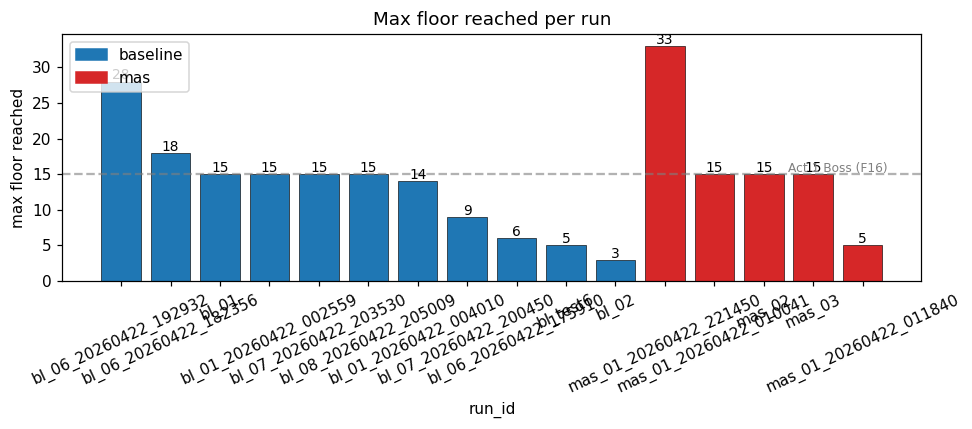

In [5]:
# Cell 4 — max floor reached by run
fig, ax = plt.subplots(figsize=(9,4))
df_sorted = df_summary.sort_values(['system','max_floor'], ascending=[True, False]).reset_index(drop=True)
colors = [SYS_COLOR[s] for s in df_sorted['system']]
bars = ax.bar(df_sorted['run_id'], df_sorted['max_floor'], color=colors, edgecolor='black', linewidth=0.4)
for x, v in zip(df_sorted['run_id'], df_sorted['max_floor']):
    ax.text(x, v + 0.3, str(int(v)), ha='center', fontsize=9)
ax.axhline(15, ls='--', c='gray', alpha=0.6)
ax.text(len(df_sorted)-0.5, 15.3, 'Act 1 Boss (F16)', fontsize=8, color='gray', ha='right')
ax.set_xlabel('run_id'); ax.set_ylabel('max floor reached'); ax.set_title('Max floor reached per run')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=SYS_COLOR['baseline'], label='baseline'),
                   Patch(color=SYS_COLOR['mas'], label='mas')], loc='upper left')
plt.xticks(rotation=25); plt.tight_layout(); plt.show()

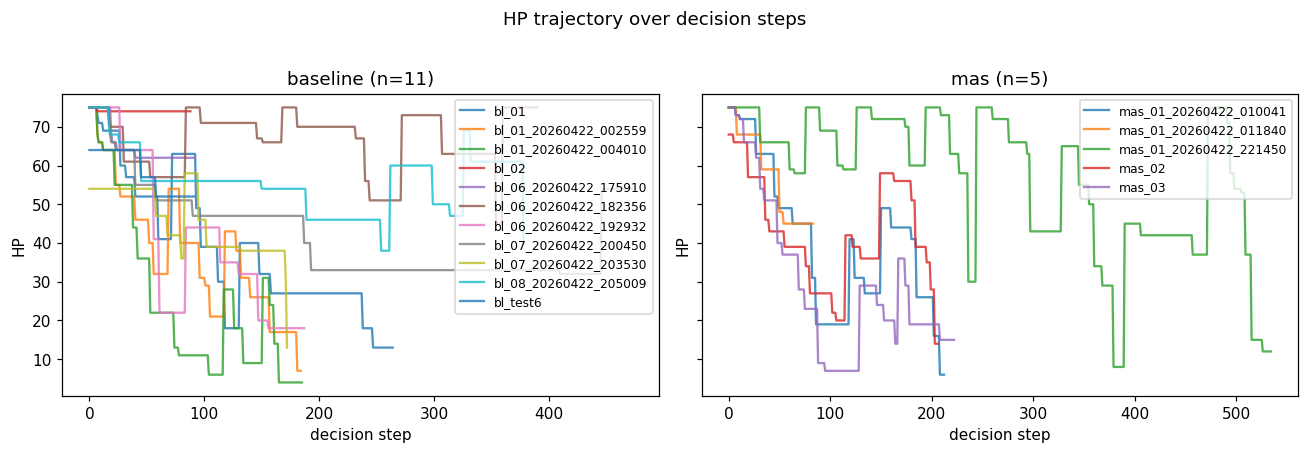

In [6]:
# Cell 5 — HP trajectory over decision steps (per run)
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
for ax, sys_ in zip(axes, ['baseline','mas']):
    sub = df_steps[df_steps['system']==sys_]
    for rid, g in sub.groupby('run_id'):
        ax.plot(g['step'], g['hp'], alpha=0.8, label=rid)
    ax.set_title(f'{sys_} (n={sub["run_id"].nunique()})')
    ax.set_xlabel('decision step'); ax.set_ylabel('HP')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle('HP trajectory over decision steps', y=1.02)
plt.tight_layout(); plt.show()

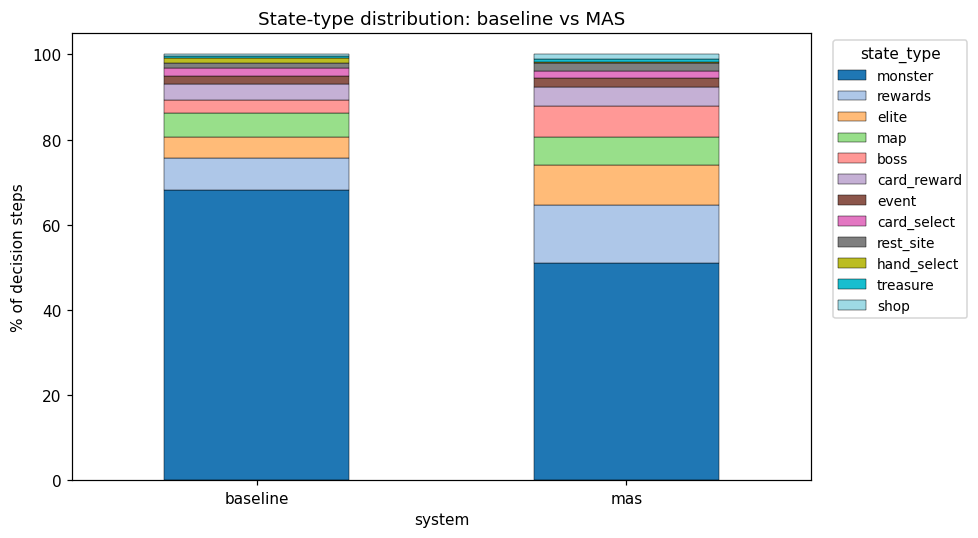

system       baseline   mas
state_type                 
monster          68.1  51.0
rewards           7.6  13.8
elite             4.9   9.3
map               5.6   6.7
boss              3.1   7.1
card_reward       3.7   4.5
event             2.0   2.1
card_select       1.9   1.7
rest_site         1.1   2.0
hand_select       1.4   0.2
treasure          0.4   0.8
shop              0.3   1.0


In [7]:
# Cell 6 — state_type time share: baseline vs MAS
share = df_steps.groupby(['system','state_type']).size().unstack(fill_value=0)
share_pct = share.div(share.sum(axis=1), axis=0) * 100
# order columns by overall frequency
col_order = share_pct.sum(axis=0).sort_values(ascending=False).index
share_pct = share_pct[col_order]

ax = share_pct.plot(kind='bar', stacked=True, figsize=(9,5), colormap='tab20', edgecolor='black', linewidth=0.3)
ax.set_ylabel('% of decision steps'); ax.set_title('State-type distribution: baseline vs MAS')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left', fontsize=9, title='state_type')
plt.tight_layout(); plt.show()
print(share_pct.round(1).T)

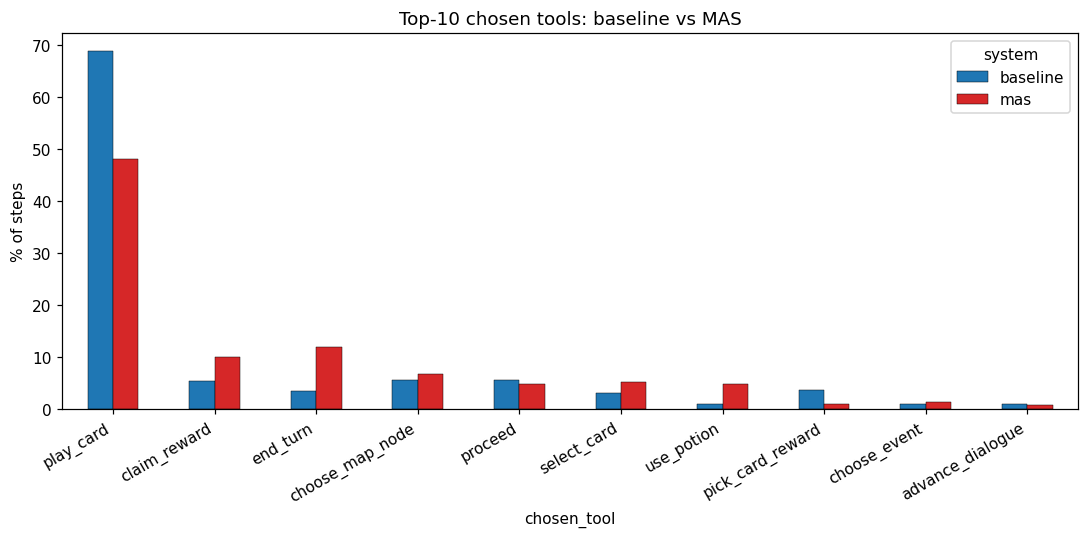

system            baseline   mas
chosen_tool                     
play_card             68.8  48.2
claim_reward           5.3  10.1
end_turn               3.4  11.9
choose_map_node        5.6   6.7
proceed                5.6   4.8
select_card            3.1   5.2
use_potion             1.0   4.8
pick_card_reward       3.7   1.0
choose_event           1.0   1.3
advance_dialogue       1.0   0.8


In [10]:
# Cell 7 — chosen_tool frequency: baseline vs MAS (top 10 tools)
tool_counts = df_steps.groupby(['system','chosen_tool']).size().unstack(fill_value=0)
tool_pct = tool_counts.div(tool_counts.sum(axis=1), axis=0) * 100
top_tools = tool_pct.sum(axis=0).sort_values(ascending=False).head(10).index
tool_top = tool_pct[top_tools]

ax = tool_top.T.plot(kind='bar', figsize=(10,5), color=[SYS_COLOR['baseline'], SYS_COLOR['mas']],
                     edgecolor='black', linewidth=0.3)
ax.set_ylabel('% of steps'); ax.set_xlabel('chosen_tool')
ax.set_title('Top-10 chosen tools: baseline vs MAS')
ax.legend(title='system')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print(tool_top.round(1).T)

IndexError: index 0 is out of bounds for axis 0 with size 0

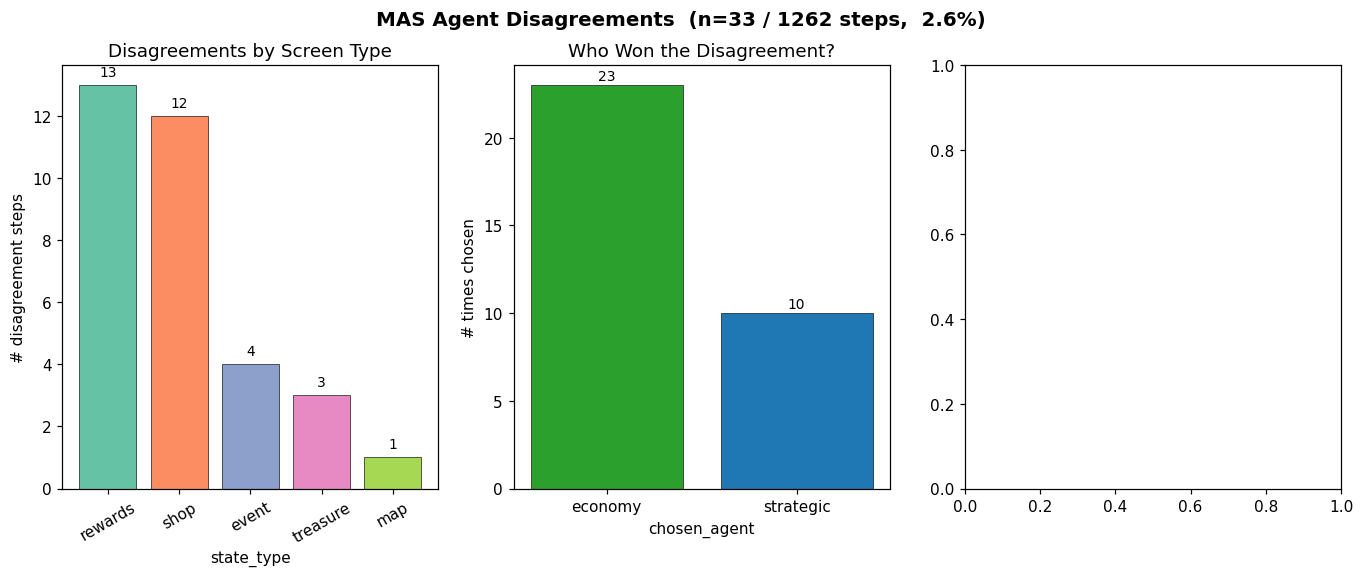

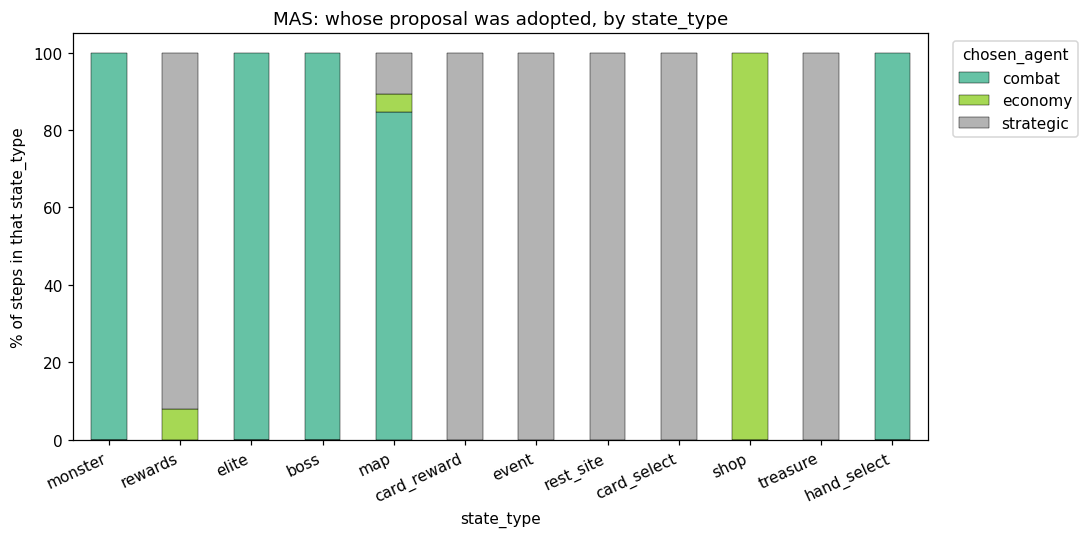


Overall MAS agent adoption:
chosen_agent
combat       923
strategic    309
economy       30

Agreement rate (all agents same action):
agreement
True     97.4
False     2.6


In [ ]:
# Cell 8 — MAS agent adoption: which agent's proposal was chosen, by state_type
mas = df_steps[df_steps['system']=='mas'].copy()
if len(mas) == 0:
    print('no MAS rows in df_steps')
else:
    adop = mas.groupby(['state_type','chosen_agent']).size().unstack(fill_value=0)
    adop_pct = adop.div(adop.sum(axis=1), axis=0) * 100
    # order rows by sample size
    row_order = adop.sum(axis=1).sort_values(ascending=False).index
    adop_pct = adop_pct.loc[row_order]

    ax = adop_pct.plot(kind='bar', stacked=True, figsize=(10,5), colormap='Set2', edgecolor='black', linewidth=0.3)
    ax.set_ylabel('% of steps in that state_type'); ax.set_xlabel('state_type')
    ax.set_title('MAS: whose proposal was adopted, by state_type')
    ax.legend(title='chosen_agent', bbox_to_anchor=(1.02,1.0), loc='upper left')
    plt.xticks(rotation=25, ha='right'); plt.tight_layout(); plt.show()

    print('\nOverall MAS agent adoption:')
    print(mas['chosen_agent'].value_counts(dropna=False).to_string())
    print('\nAgreement rate (all agents same action):')
    print(mas['agreement'].value_counts(normalize=True).mul(100).round(1).to_string())

In [ ]:
# 只看有分歧的步骤
disagreements = mas[mas['agreement'] == False].copy()

# 1. 分歧发生在哪类 state_type
print(disagreements['state_type'].value_counts())

# 2. 分歧时最终是谁赢了（哪个 agent 的提案被选中）
print(disagreements['chosen_agent'].value_counts())

# 3. 分歧时三个 agent 各自提了什么 tool
cols = ['state_type', 'combat_tool', 'strategic_tool', 'economy_tool', 'chosen_agent']
print(disagreements[cols].to_string())

state_type
rewards     13
shop        12
event        4
treasure     3
map          1
Name: count, dtype: int64
chosen_agent
economy      23
strategic    10
Name: count, dtype: int64
     state_type combat_tool    strategic_tool      economy_tool chosen_agent
2705    rewards         NaN  pick_card_reward      claim_reward      economy
2728      event         NaN      choose_event  advance_dialogue    strategic
2861      event         NaN      choose_event  advance_dialogue    strategic
3060      event         NaN      choose_event  advance_dialogue    strategic
3115    rewards         NaN  pick_card_reward      claim_reward      economy
3120       shop         NaN     select_bundle     shop_purchase      economy
3121       shop         NaN     select_bundle     shop_purchase      economy
3122       shop         NaN     select_bundle     shop_purchase      economy
3123       shop         NaN     select_bundle     shop_purchase      economy
3124       shop         NaN     select_bundle  

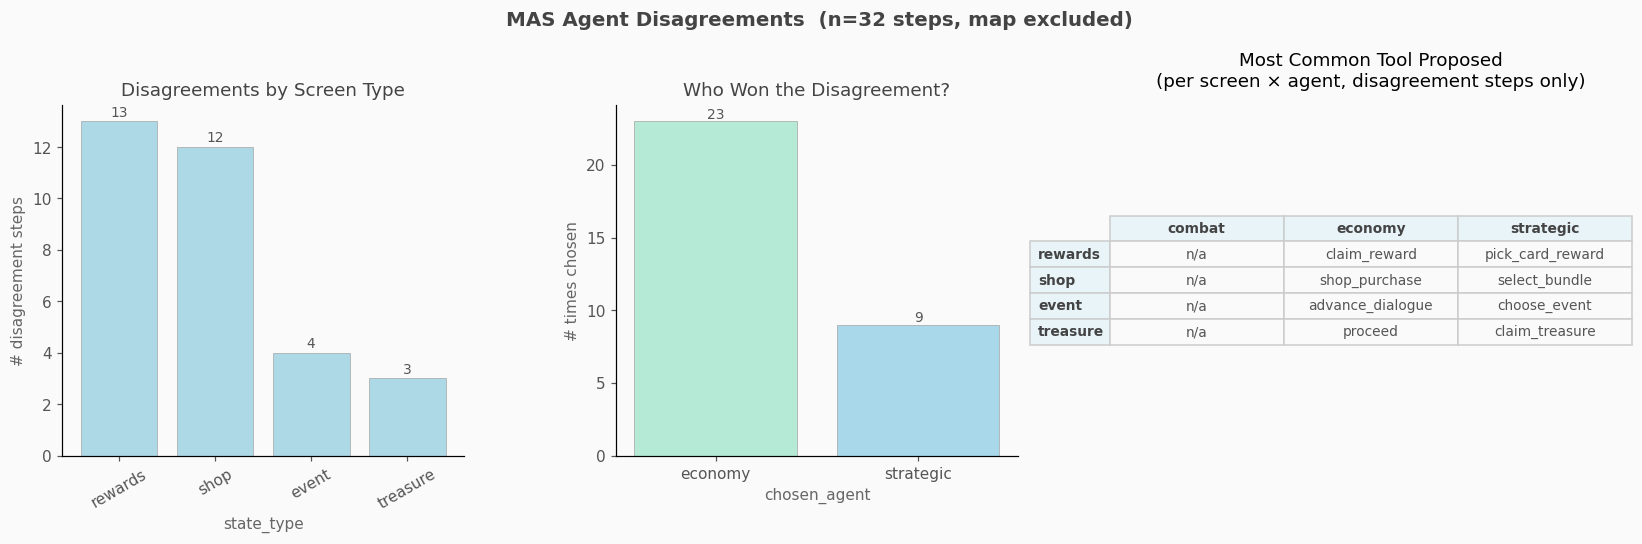


Total disagreement steps: 32

Disagreement by state_type:
state_type
rewards     13
shop        12
event        4
treasure     3

Winner (chosen_agent) in disagreements:
chosen_agent
economy      23
strategic     9


In [21]:
# Cell 9 — Where do MAS agents disagree? (disagreement breakdown by state_type + winner)
# Exclude 'map' (only 1 case, not meaningful)
EXCLUDE_STATES = {'map'}

mas = df_steps[df_steps['system'] == 'mas'].copy()
dis = mas[(mas['agreement'] == False) & (~mas['state_type'].isin(EXCLUDE_STATES))].copy()

if len(dis) == 0:
    print('No disagreement steps found.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.patch.set_facecolor('#fafafa')
    for ax in axes:
        ax.set_facecolor('#fafafa')
    fig.suptitle(f'MAS Agent Disagreements  (n={len(dis)} steps, map excluded)',
                 fontsize=13, fontweight='bold', color='#444')

    # --- Panel 1: disagreement count by state_type ---
    st_counts = dis['state_type'].value_counts()
    axes[0].bar(st_counts.index, st_counts.values, color='lightblue', edgecolor='#aaa', linewidth=0.5)
    axes[0].set_title('Disagreements by Screen Type', color='#444')
    axes[0].set_xlabel('state_type', color='#666')
    axes[0].set_ylabel('# disagreement steps', color='#666')
    axes[0].tick_params(axis='x', rotation=30, colors='#555')
    axes[0].tick_params(axis='y', colors='#555')
    axes[0].spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(st_counts.values):
        axes[0].text(i, v + 0.2, str(v), ha='center', fontsize=9, color='#555')

    # --- Panel 2: who won when agents disagreed ---
    winner_counts = dis['chosen_agent'].value_counts()
    axes[1].bar(winner_counts.index, winner_counts.values, color='lightblue', edgecolor='#aaa', linewidth=0.5)
    axes[1].set_title('Who Won the Disagreement?', color='#444')
    axes[1].set_xlabel('chosen_agent', color='#666')
    axes[1].set_ylabel('# times chosen', color='#666')
    axes[1].tick_params(colors='#555')
    axes[1].spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(winner_counts.values):
        axes[1].text(i, v + 0.2, str(v), ha='center', fontsize=9, color='#555')

    # --- Panel 3: per state_type, which tool each agent proposed ---
    st_order = [s for s in dis['state_type'].value_counts().index.tolist() if s not in EXCLUDE_STATES]
    agent_cols = [c for c in ['combat_tool', 'strategic_tool', 'economy_tool'] if c in dis.columns]
    agent_labels = [c.replace('_tool', '') for c in agent_cols]

    rows = []
    for _, row in dis.iterrows():
        for col, label in zip(agent_cols, agent_labels):
            rows.append({'state_type': row['state_type'], 'agent': label, 'tool': row[col]})
    df_dis = pd.DataFrame(rows)

    # pivot: state_type × agent → most common tool label
    def _top(x):
        vc = x.dropna().value_counts()
        return vc.index[0] if len(vc) > 0 else 'n/a'

    summary = df_dis.groupby(['state_type', 'agent'])['tool'].agg(_top).unstack(fill_value='n/a')

    axes[2].axis('off')
    col_labels = summary.columns.tolist()
    row_labels = [s for s in st_order if s in summary.index]
    cell_text = [[summary.loc[s, c] if c in summary.columns else 'n/a' for c in col_labels]
                 for s in row_labels]
    tbl = axes[2].table(
        cellText=cell_text,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellLoc='center', loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.3, 1.7)
    for (r, c_), cell in tbl.get_celld().items():
        cell.set_edgecolor('#ccc')
        if r == 0 or c_ == -1:
            cell.set_facecolor('#e8f4f8')
            cell.set_text_props(color='#444', fontweight='bold')
        else:
            cell.set_facecolor('#fafafa')
            cell.set_text_props(color='#555')
    axes[2].set_title('Most Common Tool Proposed\n(per screen × agent, disagreement steps only)', pad=12)

    plt.tight_layout()
    plt.savefig('disagreement_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'\nTotal disagreement steps: {len(dis)}')
    print('\nDisagreement by state_type:')
    print(st_counts.to_string())
    print('\nWinner (chosen_agent) in disagreements:')
    print(winner_counts.to_string())
